# Actividad 3.1 - Detección de Peatones con SVM

**Maestría en Inteligencia Artificial Aplicada (MNA)**

**Tecnológico de Monterrey**

**Curso:** Navegación Autónoma
**Equipo 9:**
* José Eduardo De Moraes López - A01634782
* Eduardo Javier Porras Herrera - AL02805437
* Angel Eduardo Urueta Puello - A01796724
* Luis Manuel Velasco Iglesias - A00226599

In [18]:
import os
import cv2
import numpy as np
import joblib
from skimage.feature import hog
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix


import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [10]:
# --- Configuración ---
HOG_ORIENTATIONS = 9
HOG_PIXELS_PER_CELL = (8, 8)
HOG_CELLS_PER_BLOCK = (2, 2)
WINDOW_SIZE = (64, 128) 


DATASET_BASE_PATH = './Daimler_Dataset' 
pos_dir = os.path.join(DATASET_BASE_PATH, 'pos')
neg_dir = os.path.join(DATASET_BASE_PATH, 'neg')

print("Librerías importadas y configuración lista.")

Librerías importadas y configuración lista.


### Feature Extraction Functions


In [13]:
def extract_hog_features(img):
    """Redimensiona y extrae características HOG de una imagen en escala de grises."""
    img_resized = cv2.resize(img, WINDOW_SIZE)
    features = hog(img_resized, 
                   orientations=HOG_ORIENTATIONS, 
                   pixels_per_cell=HOG_PIXELS_PER_CELL,
                   cells_per_block=HOG_CELLS_PER_BLOCK, 
                   transform_sqrt=True, 
                   block_norm="L2-Hys")
    return features

In [14]:
def load_data(pos_path, neg_path):
    features = []
    labels = []
    
    print(f"Cargando imágenes de peatones desde: {pos_path}")
    for filename in os.listdir(pos_path):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.pgm')):
            img = cv2.imread(os.path.join(pos_path, filename), cv2.IMREAD_GRAYSCALE)
            if img is not None:
                features.append(extract_hog_features(img))
                labels.append(1) # 1 = Peatón
                
    print(f"Cargando fondos sin peatones desde: {neg_path}")
    for filename in os.listdir(neg_path):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.pgm')):
            img = cv2.imread(os.path.join(neg_path, filename), cv2.IMREAD_GRAYSCALE)
            if img is not None:
                features.append(extract_hog_features(img))
                labels.append(0) # 0 = Fondo
                
    return np.array(features), np.array(labels)


### Data Loading

In [15]:
if not os.path.exists(pos_dir) or not os.path.exists(neg_dir):
    print(f"Error: No se encontraron las carpetas en {DATASET_BASE_PATH}")
else:
    print("Iniciando extracción de características...")
    X, y = load_data(pos_dir, neg_dir)
    print(f"Extracción completa: {len(X)} muestras totales procesadas y cargadas en memoria.")

Iniciando extracción de características...)
Cargando imágenes de peatones desde: ./Daimler_Dataset/pos
Cargando fondos sin peatones desde: ./Daimler_Dataset/neg
Extracción completa: 9800 muestras totales procesadas y cargadas en memoria.


### Splitting and Training the SVM

In [16]:
# Separar 20% para la prueba final
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Entrenando el modelo Linear SVM...")
svm_model = LinearSVC(C=1.0, max_iter=10000)
svm_model.fit(X_train, y_train)
print("¡Modelo entrenado!")

Entrenando el modelo Linear SVM...
¡Modelo entrenado!


### Evaluation and Export

In [17]:
print("--- Evaluación del Modelo ---")
predictions = svm_model.predict(X_test)

print("Matriz de Confusión:")
print(confusion_matrix(y_test, predictions))

print("\nReporte de Clasificación:")
print(classification_report(y_test, predictions))


--- Evaluación del Modelo ---
Matriz de Confusión:
[[951  41]
 [ 34 934]]

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.97      0.96      0.96       992
           1       0.96      0.96      0.96       968

    accuracy                           0.96      1960
   macro avg       0.96      0.96      0.96      1960
weighted avg       0.96      0.96      0.96      1960



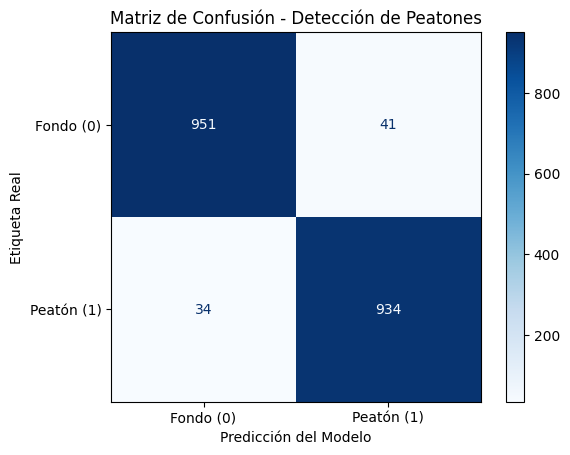

In [19]:
cm = confusion_matrix(y_test, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                              display_labels=['Fondo (0)', 'Peatón (1)'])


disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title('Matriz de Confusión - Detección de Peatones')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Etiqueta Real')


plt.show()

In [20]:
model_filename = 'svm_pedestrian_model.pkl'
joblib.dump(svm_model, model_filename)
print(f"\n¡Éxito! Modelo guardado en tu directorio actual como '{model_filename}'.")


¡Éxito! Modelo guardado en tu directorio actual como 'svm_pedestrian_model.pkl'.
